<a href="https://colab.research.google.com/github/Romina-mhm/Customer-Churn-Prediction/blob/main/Customer_Churn_Prediction_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Customer Churn Prediction — Telco Dataset

In the telecom business, churn means a customer cancels the subscription. It
is a big problem because getting a new customer costs much more than keeping
one (some studies say 5 to 7 times more). If we can predict which customers
are going to leave, the company can try to keep them with offers before they
cancel.

So the goal of this project is to predict churn from customer data. This is a
binary classification problem: for each customer, predict if they will churn
(Yes) or not (No). I also want the model to give a probability, so customers
can be ordered by risk and the company can focus on the most risky ones.

The dataset is the IBM Telco Customer Churn dataset (public, 7043 customers,
21 columns).

I compare a few models: Logistic Regression, Decision Tree, Random Forest and
a Neural Network (MLP). I also add a Dummy classifier as a baseline, just to
check the other models are really learning something. I follow the CRISP-DM
steps: understand the data, prepare it, build the models, and evaluate them.

## Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# random seed so the results are the same every run
import random, os
seed = 42
random.seed(seed)
np.random.seed(seed)
os.environ['PYTHONHASHSEED'] = str(seed)

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)   # show all columns
sns.set_theme(style='whitegrid')

## Load the data

In [ ]:
url = 'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv'
df = pd.read_csv(url)

print('Shape:', df.shape)   # (rows, columns)
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Data Understanding

First I look at the data to understand what I have: the columns, their types,
the missing values, and how each feature is related to churn.

The columns are:

| Column | Meaning |
|---|---|
| `customerID` | ID of the customer (not useful for prediction) |
| `gender` | Male / Female |
| `SeniorCitizen` | 1 if senior, 0 if not |
| `Partner`, `Dependents` | family info (Yes / No) |
| `tenure` | months as a customer |
| `PhoneService`, `MultipleLines` | phone service |
| `InternetService` | DSL / Fiber optic / No |
| `OnlineSecurity` ... `StreamingMovies` | extra services |
| `Contract` | Month-to-month / One year / Two year |
| `PaperlessBilling` | Yes / No |
| `PaymentMethod` | how the customer pays |
| `MonthlyCharges` | monthly bill |
| `TotalCharges` | total spent until now |
| `Churn` | target: Yes if the customer left |


### First look

I use `info()` to see the types and `describe()` for basic statistics. I add
`include='all'` so it also shows the text columns, not only the numbers.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df.describe(include='all').T   # .T makes it vertical, easier to read

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,3186-AJIEK,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


A few things I notice:

- 7043 rows and 21 columns.
- `TotalCharges` is type object (text), but it should be a number. I will check this later.
- `SeniorCitizen` is 0/1, so it is basically a yes/no column saved as a number.
- The numeric columns are `tenure`, `MonthlyCharges` and `TotalCharges`.
- The other columns are categories with few values.


### Target distribution

Let me see how many customers churn and how many don't. This is important
because if the classes are very unbalanced, accuracy is not a good metric.

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     0.735
Yes    0.265
Name: proportion, dtype: float64


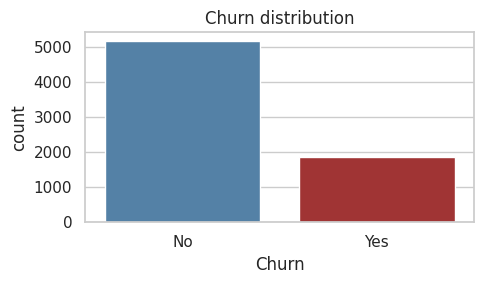

In [ ]:
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True).round(3))   # as percentages

plt.figure(figsize=(5, 3))
sns.countplot(data=df, x='Churn', palette={'No': 'steelblue', 'Yes': 'firebrick'})
plt.title('Churn distribution')
plt.tight_layout()
plt.show()

The classes are unbalanced: around 73% No and 27% Yes.

Because of this:
- Accuracy is not a good metric (a model that always says No gets 73%).
- I will use F1 and ROC-AUC instead.
- I will also use `class_weight='balanced'` in the models that support it, so the minority class gets more weight.


### Missing values

First check:

In [ ]:
df.isnull().sum().sum()   # total number of missing values

np.int64(0)

It says 0, but this is not really true. `TotalCharges` is text, so the missing
values are probably saved as empty strings, not as real NaN. I convert it to
number with `errors='coerce'`, which turns the bad values into NaN.

In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


Now there are 11 missing in `TotalCharges`. Let me look at them:

In [ ]:
df[df['TotalCharges'].isna()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


All 11 rows have `tenure = 0`. These are new customers that just signed and
were not billed yet, so they don't have a TotalCharges value. They all have
`Churn = No`.

I drop them because they are only 11 out of 7043, and I cannot really know
what their TotalCharges should be.

In [ ]:
df = df.drop(df[df['tenure'] == 0].index)   # remove the 11 rows
print('Shape after drop:', df.shape)
print('Missing now:', df.isnull().sum().sum())

Shape after drop: (7032, 21)
Missing now: 0


### Duplicates and ID

In [ ]:
print('Duplicates:', df.duplicated().sum())
print('Unique IDs:', df['customerID'].nunique(), 'out of', len(df))

Duplicates: 0
Unique IDs: 7032 out of 7032


No duplicates, and every `customerID` is unique. I will drop this column in
the preparation step because it does not help to predict churn.

### Numeric features

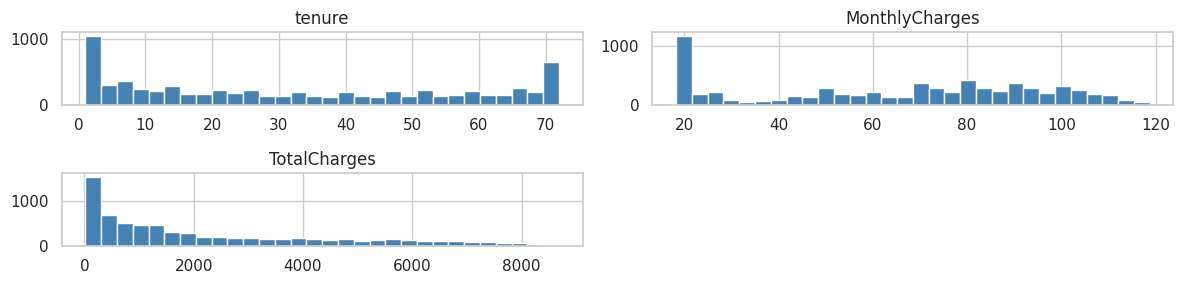

In [ ]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
df[num_cols].hist(bins=30, figsize=(12, 3), color='steelblue', edgecolor='white')
plt.tight_layout()
plt.show()

- `tenure` has two peaks: many new customers and many old customers (around the max of 72 months).
- `MonthlyCharges` also has two groups: around 20 (probably phone only) and 70-100 (full services).
- `TotalCharges` is skewed to the right because most customers are not very old.


### Categorical features

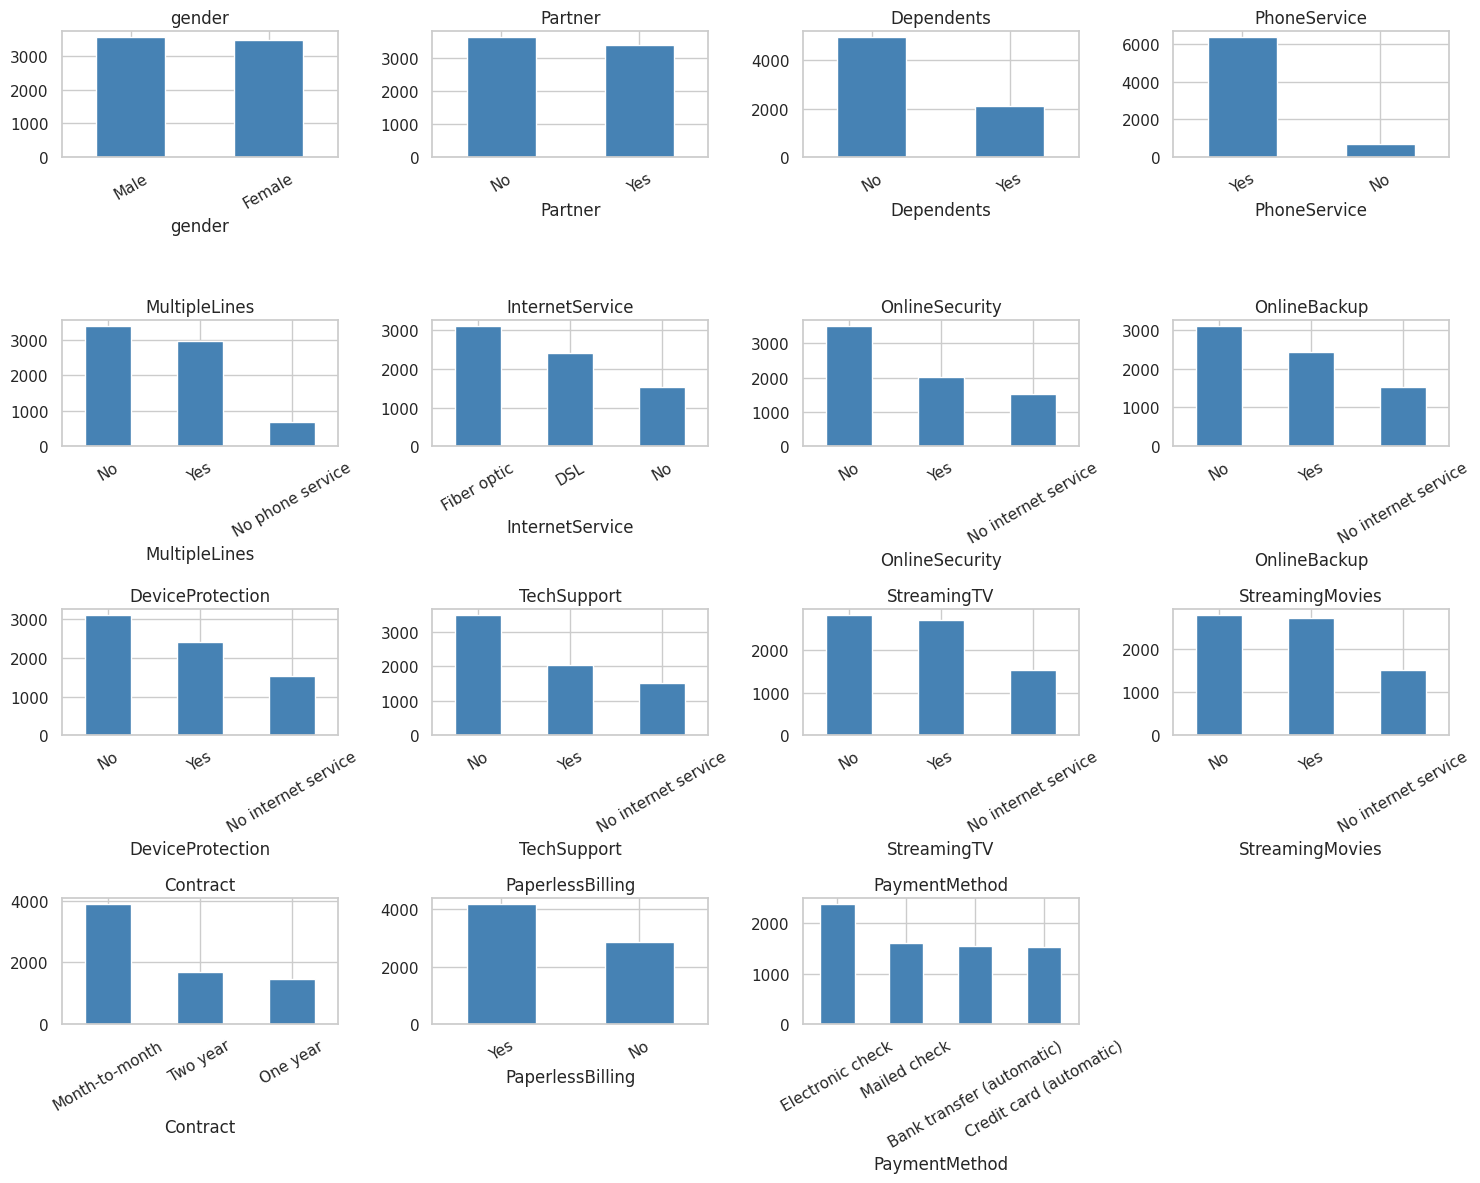

In [ ]:
# all the text columns except the target and the id
cat_cols = [c for c in df.select_dtypes(include='object').columns
            if c not in ('Churn', 'customerID')]

fig, axes = plt.subplots(4, 4, figsize=(15, 12))
for ax, col in zip(axes.flat, cat_cols):
    df[col].value_counts().plot(kind='bar', ax=ax, color='steelblue')
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=30)
for ax in axes.flat[len(cat_cols):]:   # hide empty subplots
    ax.axis('off')
plt.tight_layout()
plt.show()

- `gender` is almost 50/50.
- Most customers have phone service.
- For `Contract`, more than half are month-to-month.
- `PaymentMethod` is the most varied, electronic check is the most common.


### Numeric features vs Churn

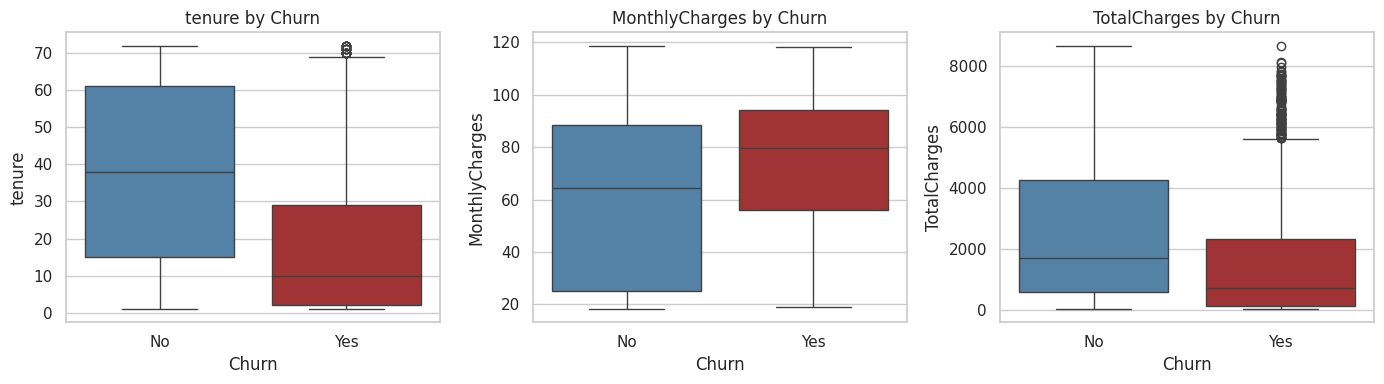

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, num_cols):
    sns.boxplot(data=df, x='Churn', y=col, ax=ax,
                palette={'No': 'steelblue', 'Yes': 'firebrick'})
    ax.set_title(f'{col} by Churn')
plt.tight_layout()
plt.show()

- Customers who churn have a much lower tenure (they leave early).
- They also pay more per month on average.
- TotalCharges is lower for them, but mostly because they stayed less time.


### Categorical features vs Churn

For each category I compute the churn rate inside it. This tells me, if a
customer is in this group, how likely they are to churn.

In [ ]:
for col in cat_cols:
    # mean of (Churn == Yes) gives the churn rate for each category value
    rate = df.groupby(col)['Churn'].apply(lambda s: (s == 'Yes').mean()).sort_values(ascending=False)
    print(f'--- {col} ---')
    print((rate * 100).round(1).astype(str) + '%')
    print()

--- gender ---
gender
Female    27.0%
Male      26.2%
Name: Churn, dtype: object

--- Partner ---
Partner
No     33.0%
Yes    19.7%
Name: Churn, dtype: object

--- Dependents ---
Dependents
No     31.3%
Yes    15.5%
Name: Churn, dtype: object

--- PhoneService ---
PhoneService
Yes    26.7%
No     25.0%
Name: Churn, dtype: object

--- MultipleLines ---
MultipleLines
Yes                 28.6%
No                  25.1%
No phone service    25.0%
Name: Churn, dtype: object

--- InternetService ---
InternetService
Fiber optic    41.9%
DSL            19.0%
No              7.4%
Name: Churn, dtype: object

--- OnlineSecurity ---
OnlineSecurity
No                     41.8%
Yes                    14.6%
No internet service     7.4%
Name: Churn, dtype: object

--- OnlineBackup ---
OnlineBackup
No                     39.9%
Yes                    21.6%
No internet service     7.4%
Name: Churn, dtype: object

--- DeviceProtection ---
DeviceProtection
No                     39.1%
Yes                   

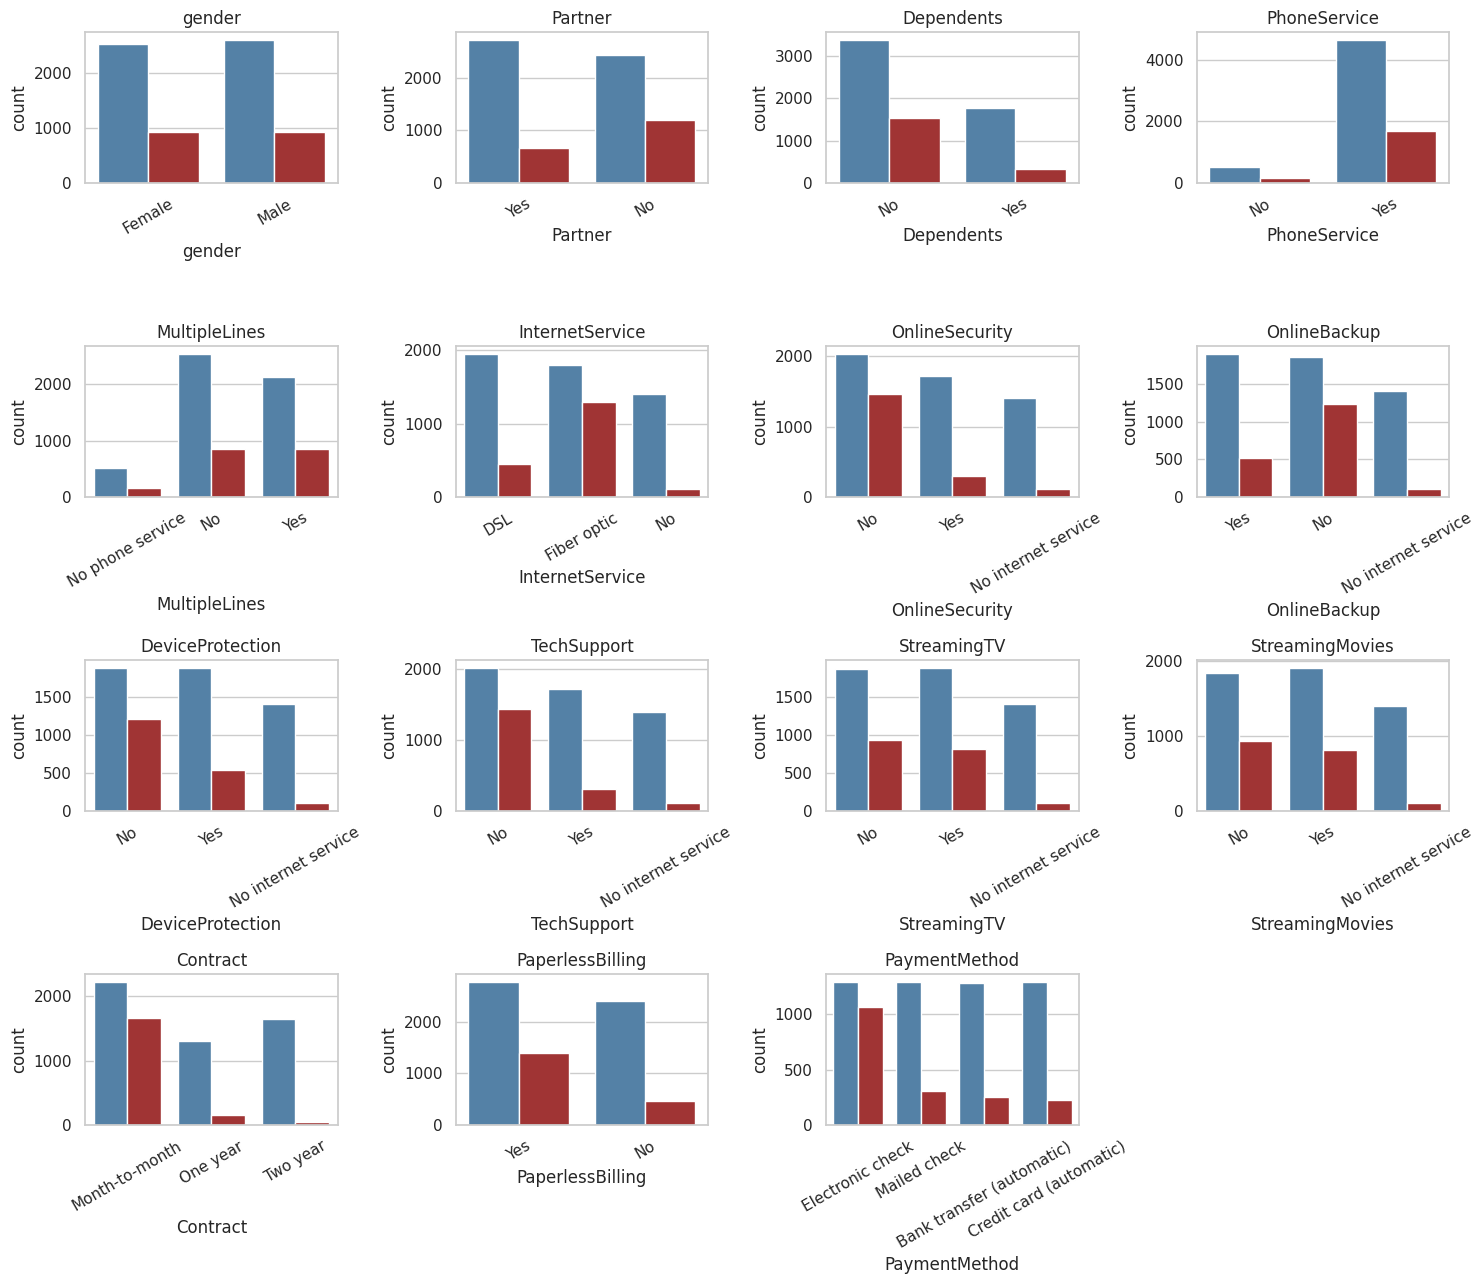

In [ ]:
fig, axes = plt.subplots(4, 4, figsize=(15, 13))
for ax, col in zip(axes.flat, cat_cols):
    sns.countplot(data=df, x=col, hue='Churn', ax=ax,
                  palette={'No': 'steelblue', 'Yes': 'firebrick'})
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=30)
    ax.legend([], [], frameon=False)   # remove the small legends
for ax in axes.flat[len(cat_cols):]:
    ax.axis('off')
plt.tight_layout()
plt.show()

The categories with the highest churn:

- `Contract = Month-to-month`: about 43% churn (Two year is only ~3%).
- `InternetService = Fiber optic`: about 42%.
- `PaymentMethod = Electronic check`: about 45%.
- `OnlineSecurity = No` and `TechSupport = No`: about 42%.

Categories that don't seem useful:
- `gender`: almost the same for Male and Female (~27%).
- `PhoneService`: almost no difference.


### Correlation

I check the correlation between the numeric features and the binary (Yes/No)
ones. I encode the Yes/No columns as 1/0 just for this plot. I don't include
the columns with more than two categories because the correlation would not
make sense for them (their numbers would be arbitrary).

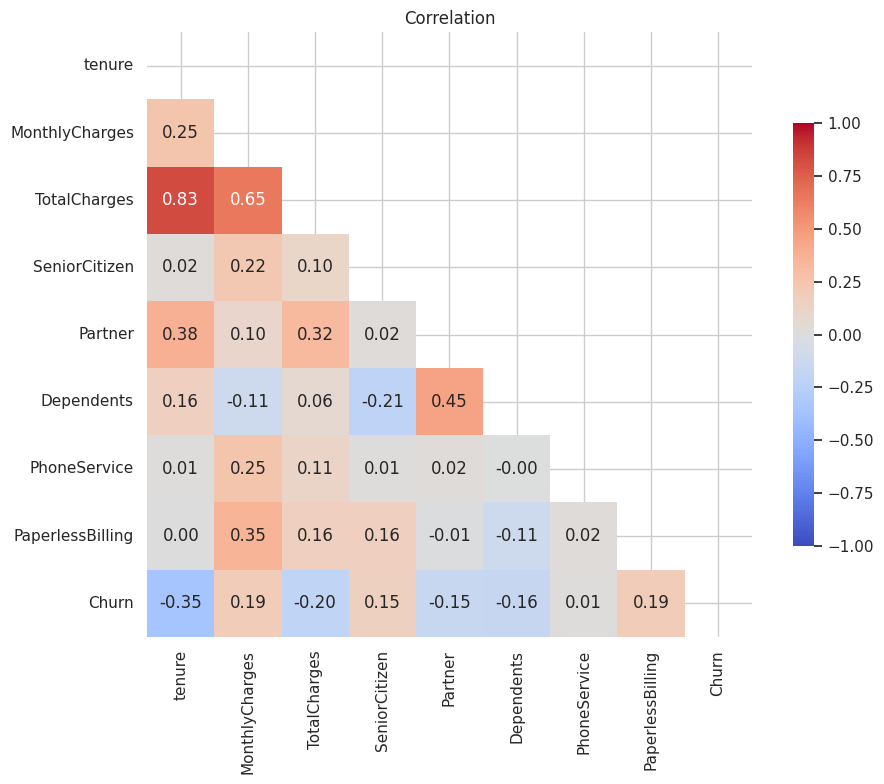

In [ ]:
# columns that have only Yes/No
yn_cols = [c for c in df.select_dtypes(include='object').columns
           if set(df[c].unique()).issubset({'Yes', 'No'})]

corr_df = df[num_cols + ['SeniorCitizen']].copy()
for c in yn_cols:
    corr_df[c] = (df[c] == 'Yes').astype(int)
corr_df['Churn'] = (df['Churn'] == 'Yes').astype(int)

corr = corr_df.corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))   # hide the upper triangle
sns.heatmap(corr, mask=mask, cmap='coolwarm', vmin=-1, vmax=1, center=0,
            annot=True, fmt='.2f', square=True, cbar_kws={'shrink': 0.7})
plt.title('Correlation')
plt.tight_layout()
plt.show()

About Churn:
- `tenure` has the strongest (negative) correlation: old customers leave less.
- `MonthlyCharges` is positive: expensive plans churn more.
- `SeniorCitizen` is a bit positive.

One thing to note: `tenure` and `TotalCharges` are very correlated (~0.83),
because TotalCharges is more or less MonthlyCharges times tenure. This can be
a problem for Logistic Regression but not for the tree models.


### Summary of the data understanding

Before going on, here is a summary of what I found and what I have to do.

| Question | Answer | What to do |
|---|---|---|
| Missing values? | 11 in TotalCharges (empty strings) | convert to number and drop them |
| Types? | 3 numeric, the rest categorical | drop customerID, encode the categories |
| Ranges? | very different (tenure 1-72, TotalCharges up to ~8700) | scale the numeric features for some models |
| How many classes? | 2 (Yes / No) | binary classification |
| Balanced? | no, 73% / 27% | use F1/ROC-AUC instead of accuracy, class_weight |
| Useful features? | Contract, tenure, InternetService, PaymentMethod | keep them all for now |


## Data Preparation

Now I prepare the data for the models. I drop the useless column, encode the
categories into numbers, and split into train and test.

### Drop the ID

In [ ]:
df = df.drop('customerID', axis=1)
print('Shape:', df.shape)

Shape: (7032, 20)


### Outliers

I check for outliers in the numeric features with the IQR rule.

In [ ]:
def iqr_outliers(s, k=1.5):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    low, up = q1 - k * iqr, q3 + k * iqr
    return ((s < low) | (s > up)).sum()

for col in num_cols:
    print(f'{col}: {iqr_outliers(df[col])} outliers')

tenure: 0 outliers
MonthlyCharges: 0 outliers
TotalCharges: 0 outliers


There are no outliers with this rule. The high TotalCharges values are just
old customers that spent more, not errors, so I keep all the data.

### Encoding

The models need numbers, not text. I use different ways depending on the
column.

**Target:** Churn becomes 1 (Yes) or 0 (No).

In [ ]:
df['Churn'] = (df['Churn'] == 'Yes').astype(int)

**Yes/No columns** become 1/0. `gender` is Male/Female, same idea.

In [ ]:
df['gender'] = (df['gender'] == 'Male').astype(int)

binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for c in binary_cols:
    df[c] = (df[c] == 'Yes').astype(int)

**Three-value columns** like MultipleLines (Yes / No / No phone service) and
the internet services (Yes / No / No internet service). The third value just
means the customer doesn't have the service, so I treat them as Yes/No (the
"No ... service" becomes No). This also makes fewer columns.

In [ ]:
three_val = ['MultipleLines', 'OnlineSecurity', 'OnlineBackup',
             'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
for c in three_val:
    df[c] = (df[c] == 'Yes').astype(int)

**Contract** has an order (month-to-month < one year < two year), so I map it
to 0, 1, 2.

In [ ]:
df['Contract'] = df['Contract'].map({'Month-to-month': 0, 'One year': 1, 'Two year': 2})

**InternetService** and **PaymentMethod** have no order, so I use one-hot
encoding: one new column (0/1) for each possible value.

In [ ]:
df = pd.get_dummies(df, columns=['InternetService', 'PaymentMethod'],
                    drop_first=False, dtype=int)

print('Shape after encoding:', df.shape)
df.head()

Shape after encoding: (7032, 25)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,InternetService_DSL,InternetService_Fiber optic,InternetService_No,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,0,0,1,0,0,0,0,0,1,29.85,29.85,0,1,0,0,0,0,1,0
1,1,0,0,0,34,1,0,1,0,1,0,0,0,1,0,56.95,1889.50,0,1,0,0,0,0,0,1
2,1,0,0,0,2,1,0,1,1,0,0,0,0,0,1,53.85,108.15,1,1,0,0,0,0,0,1
3,1,0,0,0,45,0,0,1,0,1,1,0,0,1,0,42.30,1840.75,0,1,0,0,1,0,0,0
4,0,0,0,0,2,1,0,0,0,0,0,0,0,0,1,70.70,151.65,1,0,1,0,0,0,1,0


### Train/test split

I split into 2/3 train and 1/3 test. The test set is kept aside and used only
at the end, to check how the models work on data they never saw.

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=1/3, random_state=seed
)

print('Train:', X_train.shape, 'churn rate:', round(y_train.mean(), 3))
print('Test: ', X_test.shape, 'churn rate:', round(y_test.mean(), 3))

Train: (4688, 24) churn rate: 0.268
Test:  (2344, 24) churn rate: 0.262


The churn rate in train and test is close, so the split looks fine.

About scaling: the numeric features have very different ranges. Some models
(Logistic Regression, MLP) work better with scaled data, but the tree models
don't need it. So I will add a `StandardScaler` only for the models that need
it, inside a pipeline, so the scaler is computed only on the training part and
there is no leakage from the test set.

## Modeling

Now I train the models. I use cross-validation on the training set to choose
the hyperparameters, and I keep the test set only for the final evaluation.

I compare 5 models:
- Dummy (baseline that always predicts the majority class)
- Logistic Regression
- Decision Tree
- Random Forest
- Neural Network (MLP)

In [ ]:
from sklearn.model_selection import KFold, cross_validate, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score,
                             confusion_matrix, ConfusionMatrixDisplay, roc_curve)

# 5-fold cross validation
cv = KFold(n_splits=5, shuffle=True, random_state=seed)

# metrics I want to compute during cross validation
SCORING = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

def eval_cv(name, model):
    # run cross validation and return the average of each metric
    res = cross_validate(model, X_train, y_train, cv=cv, scoring=SCORING, n_jobs=-1)
    out = {s: res['test_' + s].mean() for s in SCORING}
    out['name'] = name
    print(f'{name:20s} F1={out["f1"]:.3f}  ROC-AUC={out["roc_auc"]:.3f}  Recall={out["recall"]:.3f}')
    return out

cv_results = []   # I store the result of each model here

### Dummy (baseline)

This model always predicts the most frequent class (No). It is not useful, it
is just a baseline. If a real model cannot beat this, something is wrong.

In [ ]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy='most_frequent', random_state=seed)
cv_results.append(eval_cv('Dummy', dummy))

Dummy                F1=0.000  ROC-AUC=0.500  Recall=0.000


As expected the Dummy has F1 = 0 and ROC-AUC = 0.5: it never predicts churn.
This confirms accuracy alone would be misleading.

### Logistic Regression

A simple linear model. It needs scaled data, so I put a StandardScaler and the
model together in a pipeline. I try a few values of `C` (the regularization)
with grid search.

In [ ]:
from sklearn.linear_model import LogisticRegression

lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=seed)),
])

# try different C values, pick the best by F1
lr_grid = GridSearchCV(lr_pipe, {'clf__C': [0.1, 1, 10]}, cv=cv, scoring='f1', n_jobs=-1)
lr_grid.fit(X_train, y_train)
best_lr = lr_grid.best_estimator_

print('Best C:', lr_grid.best_params_['clf__C'])
cv_results.append(eval_cv('Logistic Regression', best_lr))

Best C: 0.1
Logistic Regression  F1=0.630  ROC-AUC=0.844  Recall=0.800


### Decision Tree

A tree that splits the data with simple rules. It is easy to understand. Trees
don't need scaling. I tune the depth and the minimum samples per leaf to avoid
overfitting.

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_grid = GridSearchCV(
    DecisionTreeClassifier(class_weight='balanced', random_state=seed),
    {'max_depth': [5, 10, None], 'min_samples_leaf': [1, 5, 20]},
    cv=cv, scoring='f1', n_jobs=-1
)
dt_grid.fit(X_train, y_train)
best_dt = dt_grid.best_estimator_

print('Best params:', dt_grid.best_params_)
cv_results.append(eval_cv('Decision Tree', best_dt))

Best params: {'max_depth': 5, 'min_samples_leaf': 5}
Decision Tree        F1=0.625  ROC-AUC=0.831  Recall=0.762


### Random Forest

This is a set of many decision trees combined together (it usually works
better than a single tree). I tune the number of trees and the depth.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_grid = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=seed, n_jobs=-1),
    {'n_estimators': [100, 200], 'max_depth': [10, 20, None]},
    cv=cv, scoring='f1', n_jobs=-1
)
rf_grid.fit(X_train, y_train)
best_rf = rf_grid.best_estimator_

print('Best params:', rf_grid.best_params_)
cv_results.append(eval_cv('Random Forest', best_rf))

Best params: {'max_depth': 10, 'n_estimators': 100}
Random Forest        F1=0.633  ROC-AUC=0.844  Recall=0.691


### Neural Network (MLP)

A small neural network with one or two hidden layers. It also needs scaling,
so again I use a pipeline. I try a couple of architectures.

In [ ]:
from sklearn.neural_network import MLPClassifier

mlp_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', MLPClassifier(random_state=seed, max_iter=300, early_stopping=True)),
])

mlp_grid = GridSearchCV(
    mlp_pipe,
    {'clf__hidden_layer_sizes': [(50,), (100,)], 'clf__alpha': [0.0001, 0.001]},
    cv=cv, scoring='f1', n_jobs=-1
)
mlp_grid.fit(X_train, y_train)
best_mlp = mlp_grid.best_estimator_

print('Best params:', mlp_grid.best_params_)
cv_results.append(eval_cv('MLP', best_mlp))

Best params: {'clf__alpha': 0.001, 'clf__hidden_layer_sizes': (100,)}
MLP                  F1=0.592  ROC-AUC=0.840  Recall=0.537


## Evaluation

Now I check the models on the test set (the data they never saw). I compute
all the metrics and put them in one table.

In [ ]:
# the dummy needs to be fitted on the training data first
dummy.fit(X_train, y_train)

models = [
    ('Dummy', dummy),
    ('Logistic Regression', best_lr),
    ('Decision Tree', best_dt),
    ('Random Forest', best_rf),
    ('MLP', best_mlp),
]

rows = []
for name, m in models:
    y_pred = m.predict(X_test)
    y_proba = m.predict_proba(X_test)[:, 1]   # probability of churn
    rows.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba),
    })

results = pd.DataFrame(rows).set_index('Model').round(3).sort_values('F1', ascending=False)
results

,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Logistic Regression,0.745,0.508,0.801,0.622,0.842
Random Forest,0.773,0.553,0.700,0.618,0.837
Decision Tree,0.737,0.499,0.749,0.599,0.819
MLP,0.797,0.641,0.510,0.568,0.837
Dummy,0.738,0.000,0.000,0.000,0.500


From the table:
- The Dummy has F1 = 0, useless as expected.
- Random Forest and Logistic Regression get the best F1.
- The ROC-AUC of the good models is around 0.84.
- The models with `class_weight='balanced'` have higher recall (they catch more churners) but lower precision.


### Confusion matrices

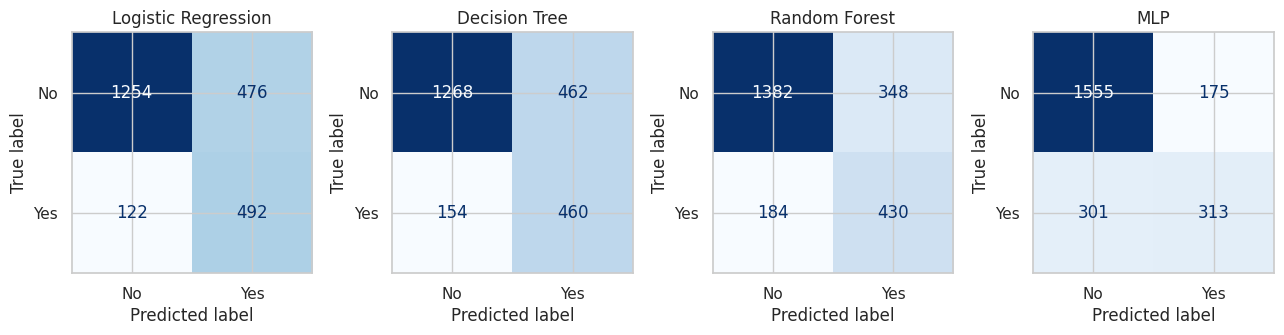

In [ ]:
top3 = results.head(4).index.tolist()
top3_models = [(n, m) for n, m in models if n in top3]

fig, axes = plt.subplots(1, 4, figsize=(13, 4))
for ax, (name, m) in zip(axes, top3_models):
    cm = confusion_matrix(y_test, m.predict(X_test))
    ConfusionMatrixDisplay(cm, display_labels=['No', 'Yes']).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name)
plt.tight_layout()
plt.show()

### ROC curves

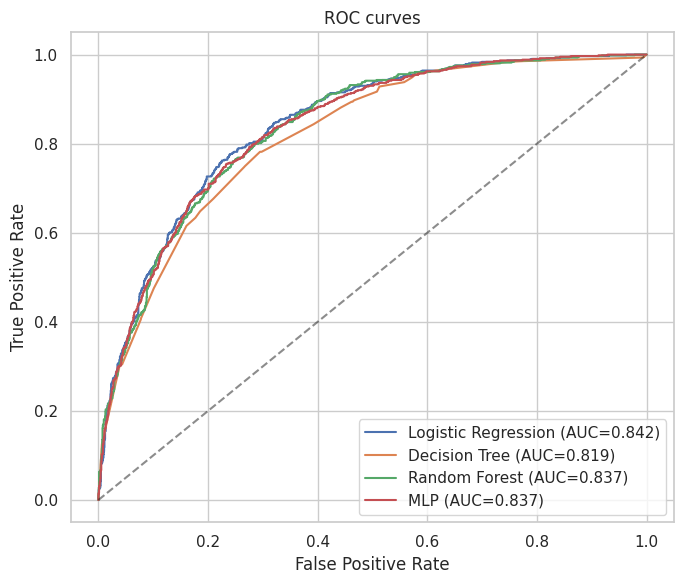

In [ ]:
plt.figure(figsize=(7, 6))
for name, m in models:
    if name == 'Dummy':
        continue
    y_proba = m.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC={roc_auc_score(y_test, y_proba):.3f})')

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)   # random line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curves')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### Feature importance

The Random Forest can tell which features it used the most. This is useful to
understand what drives churn.

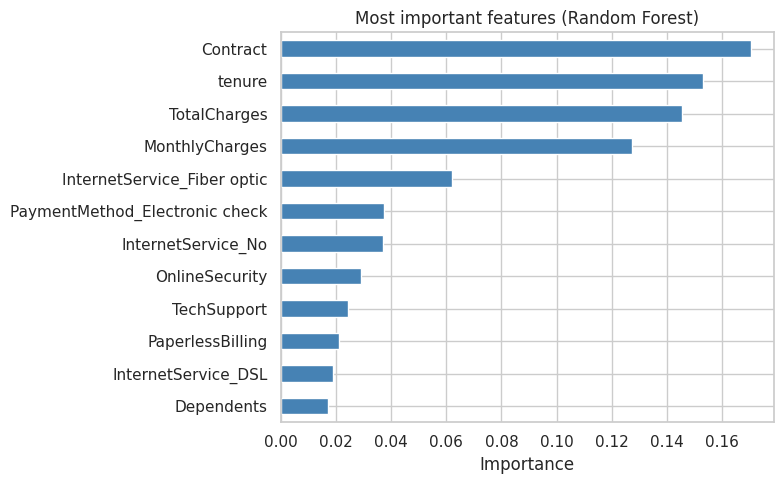

In [ ]:
importances = pd.Series(best_rf.feature_importances_, index=X_train.columns)
importances = importances.sort_values().tail(12)

plt.figure(figsize=(8, 5))
importances.plot(kind='barh', color='steelblue')
plt.title('Most important features (Random Forest)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

The most important features are the contract type, the tenure, the monthly and
total charges, and the type of internet service and payment. This matches what
I saw in the data understanding: customers with month-to-month contracts, short
tenure, fiber optic internet and electronic check payment churn the most.

## Conclusions

In this project I built a model to predict customer churn on the Telco dataset,
following the CRISP-DM steps. Logistic Regression and Random Forest gave the
best results (F1 around 0.62, ROC-AUC around 0.84). I would pick Logistic
Regression because it is simpler. The Dummy baseline (F1 = 0) confirms the
other models are really learning.

For churn, missing a real churner (FN) costs much more than flagging a wrong
customer (FP): the company loses the future revenue of that customer
versus a small retention offer. For this reason I focused on recall
and used `class_weight='balanced'` to push the models to catch more churners.
Accuracy is misleading here because the data is unbalanced (always predicting
No already gives 73%).

The most important features are contract type, tenure, internet service and
payment method. Customers with month-to-month contracts, short tenure, fiber
optic internet and electronic check payment are the most at risk, so the
retention offers can target them first.